In [1]:
from preprocessing import preprocess_data
from feature_engineering import run_feature_engineering
from make_model import train_and_evaluate
from feature_importance import analyze_feature_importance
from feature_importance import plot_feature_importance
from inference import predict_score
from verify_training_data import diagnose_training_data
from plot_trees import visualize_model_tree

### Preprocessing
Raw data from multiple rides with the earable is combined into a master `.csv` per sensors, e.g. `master_gyroscope.csv`. Folders with raw data are stored in the same directory as this file, where the last digit character of the folder name is the distraction score.

In [2]:
preprocess_data()

Starting data preprocessing...
Saved Labels: ./processed/y_labels.csv (25 rides labeled)
Saved Sensor Data: ./processed/master_temperature_sensor.csv (38682 total rows across all rides)
Saved Sensor Data: ./processed/master_optical_temperature_sensor.csv (48665 total rows across all rides)
Saved Sensor Data: ./processed/master_barometer.csv (38682 total rows across all rides)
Saved Sensor Data: ./processed/master_accelerometer.csv (618353 total rows across all rides)
Saved Sensor Data: ./processed/master_photoplethysmography.csv (309962 total rows across all rides)
Saved Sensor Data: ./processed/master_magnetometer.csv (618301 total rows across all rides)
Saved Sensor Data: ./processed/master_gyroscope.csv (618335 total rows across all rides)

Preprocessing complete, data is ready for tsfresh feature extraction


### Feature engineering using tsfresh
The master `.csv` is processed by tsfresh to extract features such as maximum value, standard deviation, median, etc. which can be processed by XGBoost. Exclude sensors by putting them in the `exclude_sensor` list.

In [3]:
# exclude_sensors = ["optical_temperature_sensor", "accelerometer", "gyroscope", "magnetometer", "barometer", "photoplethysmography", "temperature_sensor"]

run_feature_engineering(exclude_sensors=[])

Starting tsfresh feature engineering...
Extracting features for: barometer


Feature Extraction: 100%|██████████| 25/25 [00:00<00:00, 475.86it/s]


Extracting features for: photoplethysmography


Feature Extraction: 100%|██████████| 100/100 [00:00<00:00, 369.75it/s]


Extracting features for: optical_temperature_sensor


...

Extracting features for: gyroscope


Feature Extraction: 100%|██████████| 75/75 [00:00<00:00, 346.00it/s]


Extracting features for: accelerometer


Feature Extraction: 100%|██████████| 75/75 [00:00<00:00, 159.37it/s]



Merging data...
Total features kept for training: 160

Success, final dataset saved to: ./training_data/X_selected_features.csv


### Train and evaluate model using XGBoost

In [4]:
train_and_evaluate(custom_labels=False)

Dataset ready: 25 rides, 160 features per ride.
Evaluating model using Leave-One-Out Cross-Validation...

MODEL PERFORMANCE
Mean Absolute Error (MAE): 0.63
Root Mean Squared Error (RMSE): 0.75
The model's guesses are off by an average of 0.63 points on the 0-4 scale.

Training final production model on 100% of the data...
Trained model saved to: ./models/model.json


### Evaluate feature importance of model
XGBoost has built-in functions to show the importance per feature.


Top 15 Most Important Features for Predicting Distraction:
----------------------------------------------------------------------
Rank  | Feature Name                                  | Importance Score
----------------------------------------------------------------------
1     | GYROSCOPE_Z__standard_deviation               | 0.1111
2     | ACCELEROMETER_X__absolute_maximum             | 0.0914
3     | GYROSCOPE_X__standard_deviation               | 0.0888
4     | GYROSCOPE_Y__standard_deviation               | 0.0669
5     | MAGNETOMETER_Z__minimum                       | 0.0562
6     | GYROSCOPE_Z__minimum                          | 0.0549
7     | ACCELEROMETER_Y__standard_deviation           | 0.0465
8     | MAGNETOMETER_Z__standard_deviation            | 0.0463
9     | ACCELEROMETER_Z__minimum                      | 0.0392
10    | GYROSCOPE_Y__maximum                          | 0.0371
11    | GYROSCOPE_X__maximum                          | 0.0327
12    | GYROSCOPE_Z__maximum    

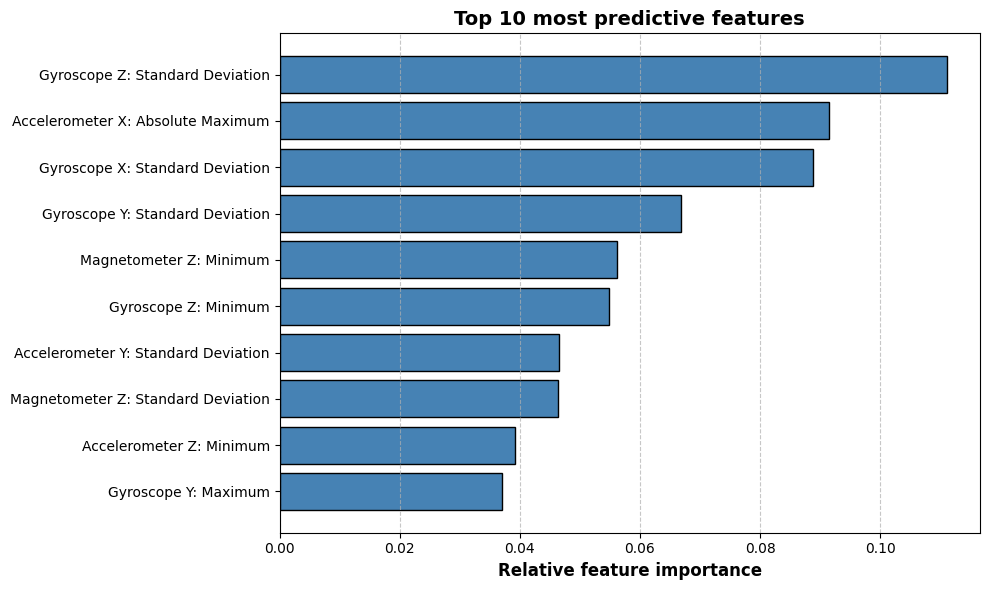

In [2]:
analyze_feature_importance()
plot_feature_importance()

### Run inference on a single ride
To run inference on a single ride (folder), give `new_ride_folder="..."` as an argument and the model will give a distraction score.

In [6]:
score = predict_score(new_ride_folder="demo_runs/OpenWearable_Recording_2026-04-14T150043.230526_3_demo")

Processing new ride: OpenWearable_Recording_2026-04-14T150043.230526_3_demo
Calculated distraction score: 2.84 / 4.0


### Upload to firebase
First, the model predicts the distraction score on 2 runs from the training set: a focused ride and a distracted ride. Then, the score is uploaded to a Firebase database so that it can be read by the Android app. To change the score that is uploaded, set `score = score_good` or `score = score_bad`

In [7]:
import firebase_admin
from firebase_admin import credentials, db

# run inference on 2 training data rides
score_good = round(float(predict_score(new_ride_folder="demo_runs/OpenWearable_Recording_2026-04-13T165421.457898_0")) + 1, 1)
score_bad = round(float(predict_score(new_ride_folder="demo_runs/OpenWearable_Recording_2026-03-26T101341.966067_4"))+1, 1)
score = score_good # pick one of the two scores to send to Firebase

# reset any existing Firebase app
if firebase_admin._apps:
    firebase_admin.delete_app(firebase_admin.get_app())

# initialize fresh with the database URL
cred = credentials.Certificate("serviceAccountKey.json")
firebase_admin.initialize_app(cred, {
    "databaseURL": "https://distraction-score-default-rtdb.europe-west1.firebasedatabase.app"
})

# send the score to Realtime Database
ref = db.reference("scores/latest")
ref.set({
    "distraction_score": score
})

print(f"Sent score {score} to Firebase!")

Processing new ride: OpenWearable_Recording_2026-04-13T165421.457898_0
Calculated distraction score: 0.34 / 4.0
Processing new ride: OpenWearable_Recording_2026-03-26T101341.966067_4
Calculated distraction score: 3.65 / 4.0
Sent score 1.3 to Firebase!


### Check scores for all the rides in the training data
Gives a list of rides used in training the model and their scores according to the model

In [19]:
diagnose_training_data()

Loading data and model for diagnostics...

Ride ID (Shortened)       | True Score | Predicted  | Error     
-----------------------------------------------------------------
2026-03-26T101341.966067  | 4.0        | 3.78       | 0.22      
2026-03-26T101935.303786  | 3.0        | 2.85       | 0.15      
2026-03-26T102512.493306  | 2.0        | 2.02       | 0.02      
2026-03-26T103015.953397  | 1.0        | 1.05       | 0.05      
2026-03-26T103513.282691  | 0.0        | 0.30       | 0.30      
2026-03-26T105712.346697  | 4.0        | 3.42       | 0.58      
2026-03-26T110257.381741  | 3.0        | 2.93       | 0.07      
2026-03-26T110809.275003  | 2.0        | 2.05       | 0.05      
2026-03-26T111245.688277  | 1.0        | 1.17       | 0.17      
2026-03-26T111650.158656  | 0.0        | 0.45       | 0.45      
2026-03-26T112950.696222  | 4.0        | 3.54       | 0.46      
2026-03-26T113555.625881  | 3.0        | 3.06       | 0.06      
2026-04-13T164718.788978  | 2.0        | 1.87 

### Visualize decision trees generated by XGBoost
Creates figures for the first `j` desicion trees generated by XGBoost (of the 50). `visualize` can be set to false to not show the figure.

Saved 1 tree visualizations to: ./models/trees_graphs


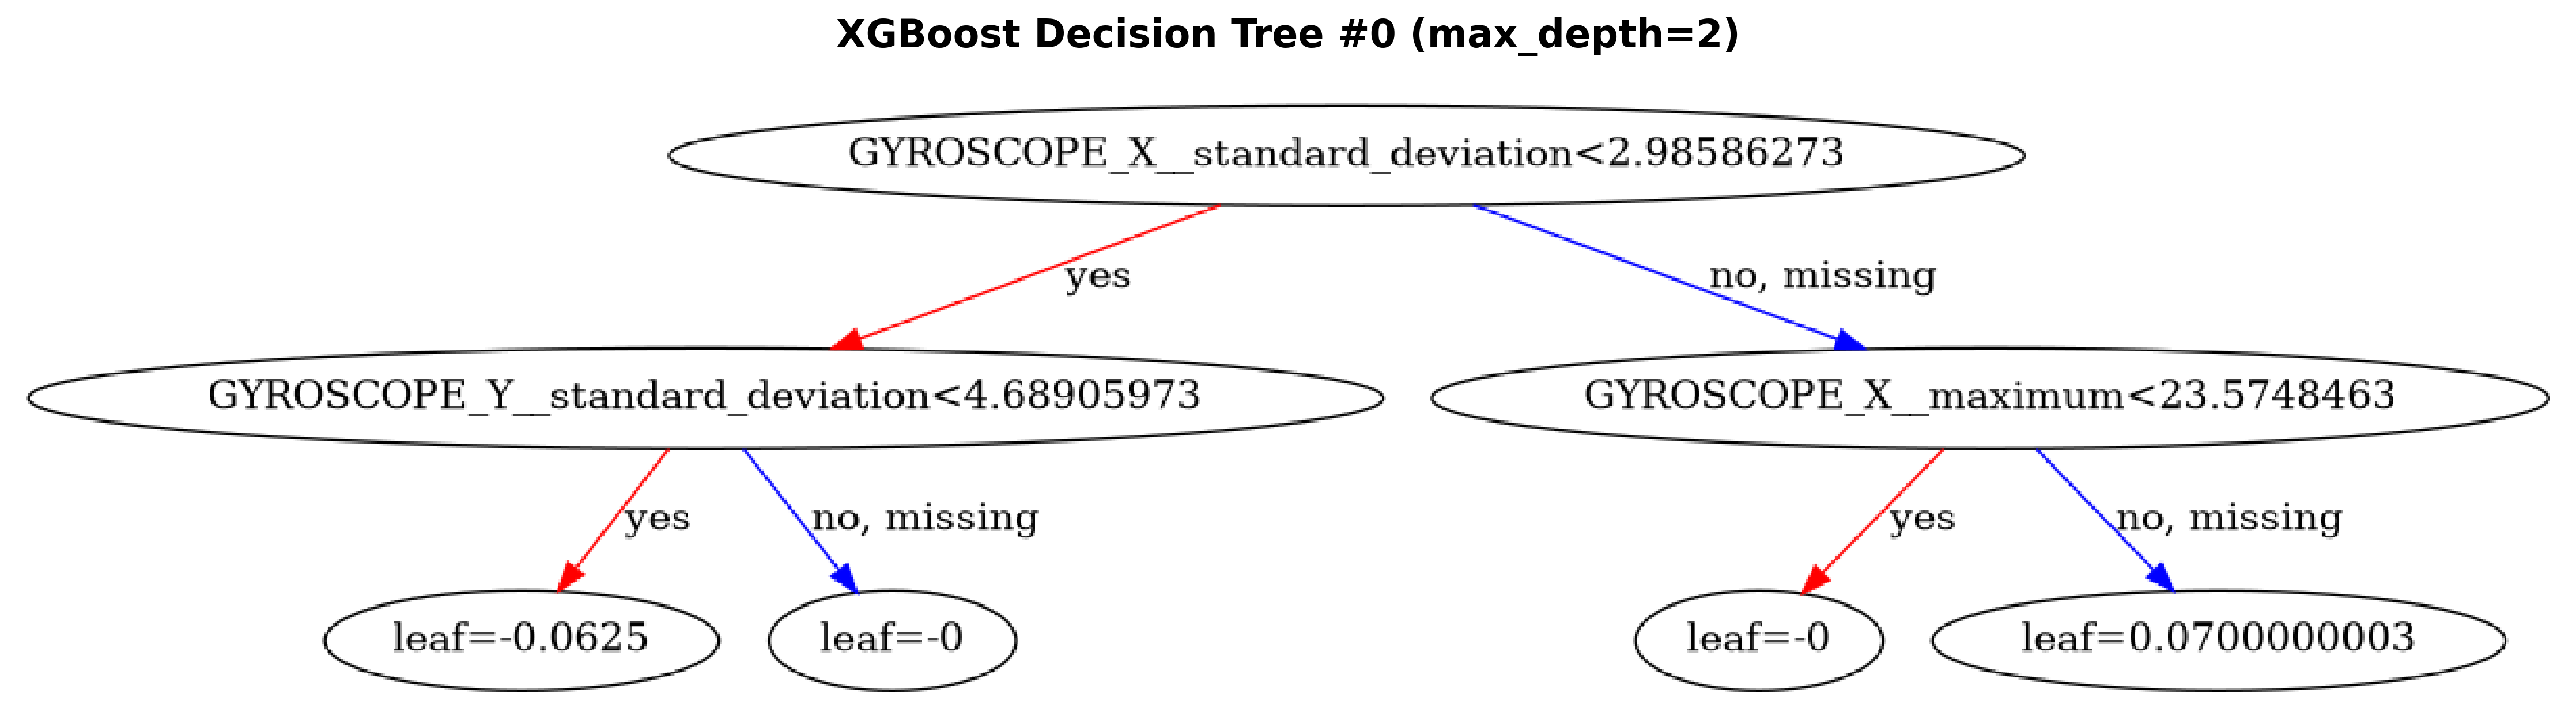

In [5]:
visualize_model_tree(visualize=True, j=1)

### Clear processed data and model
Clear data to show the preprocessing and model training from beginning to end

In [3]:
# uncomment to clear data and model
import shutil
shutil.rmtree("processed")
shutil.rmtree("models")
shutil.rmtree("training_data")